# Dataset 1: Predict Students' Dropout and Academic Success

This notebook walks through a complete ML classification pipeline on student enrollment data. The task is to predict whether a student will Drop Out, stay Enrolled, or Graduate.

Key challenges: class imbalance, 36 features, three-class classification.

## Step 1 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Step 2 — Load and Explore the Dataset

In [ ]:
df = pd.read_csv('students_dropout.csv')
print(f'Dataset Shape: {df.shape}')
print(f'\nFeature Count: {df.shape[1] - 1}')
print(f'\nTarget Distribution:')
print(df['Target'].value_counts())
print(f'\nTarget Percentage:')
print(round(df['Target'].value_counts(normalize=True) * 100, 2))

Dataset Shape: (4424, 37)

Feature Count: 36

Target Distribution:
Target
Graduate    2239
Dropout     1384
Enrolled     801
Name: count, dtype: int64

Target Percentage:
Target
Graduate    50.61
Dropout     31.28
Enrolled    18.11
Name: proportion, dtype: float64


In [ ]:
# Check for missing values
print('Missing Values Per Column:')
print(df.isnull().sum().sum())

print(f'\nData Types:')
print(df.dtypes.value_counts())

Missing Values Per Column:
0

Data Types:
int64      29
float64     7
str         1
Name: count, dtype: int64


In [ ]:
# First 5 rows
df.head()

,Marital_Status,Application_Mode,Application_Order,Course,Daytime_Evening_Attendance,Previous_Qualification,Previous_Qualification_Grade,Nacionality,Mothers_Qualification,Fathers_Qualification,...,Curricular_Units_2nd_Sem_Credited,Curricular_Units_2nd_Sem_Enrolled,Curricular_Units_2nd_Sem_Evaluations,Curricular_Units_2nd_Sem_Approved,Curricular_Units_2nd_Sem_Grade,Curricular_Units_2nd_Sem_Without_Evaluations,Unemployment_Rate,Inflation_Rate,GDP,Target
0,1,17,6,9130,0,12,126.8,8,19,28,...,5,7,18,4,5.5,7,14.7,3.4,2.67,Graduate
1,6,16,8,9119,0,12,102.0,20,6,2,...,12,6,3,11,13.0,7,14.9,2.6,1.92,Graduate
2,2,15,9,9130,1,10,130.3,5,10,1,...,11,17,1,12,13.9,2,12.0,2.4,-1.97,Dropout
3,2,10,1,9070,1,10,132.0,2,12,9,...,7,12,25,5,11.1,1,11.2,-0.7,-1.71,Graduate
4,1,10,5,9003,1,2,148.9,12,17,22,...,10,10,11,0,3.0,5,15.9,2.3,0.37,Dropout


## Step 3 — Exploratory Data Analysis (EDA)

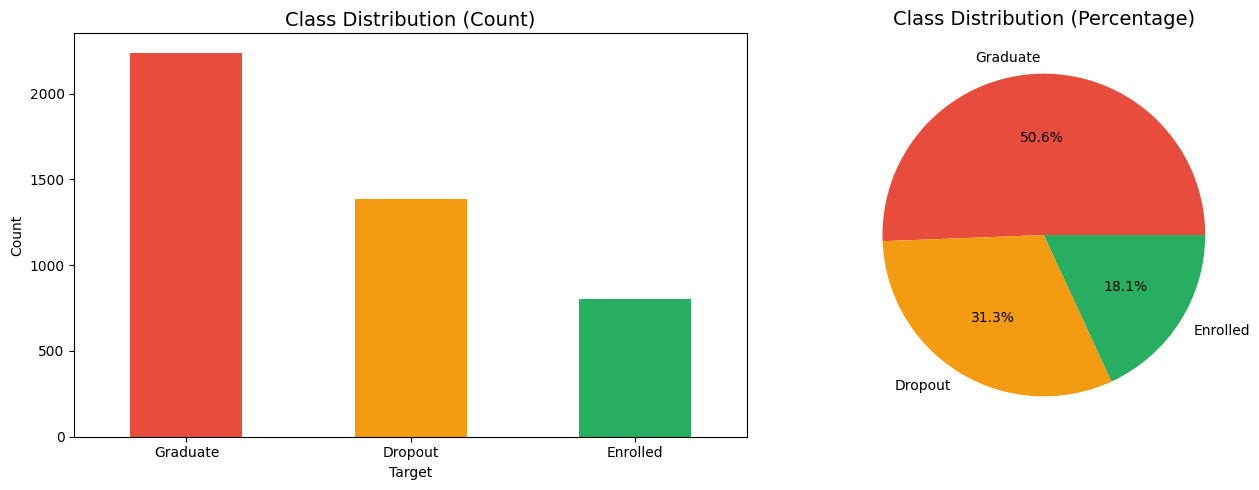

In [ ]:
# Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
df['Target'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#f39c12','#27ae60'])
axes[0].set_title('Class Distribution (Count)', fontsize=14)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['Target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#e74c3c','#f39c12','#27ae60'])
axes[1].set_title('Class Distribution (Percentage)', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

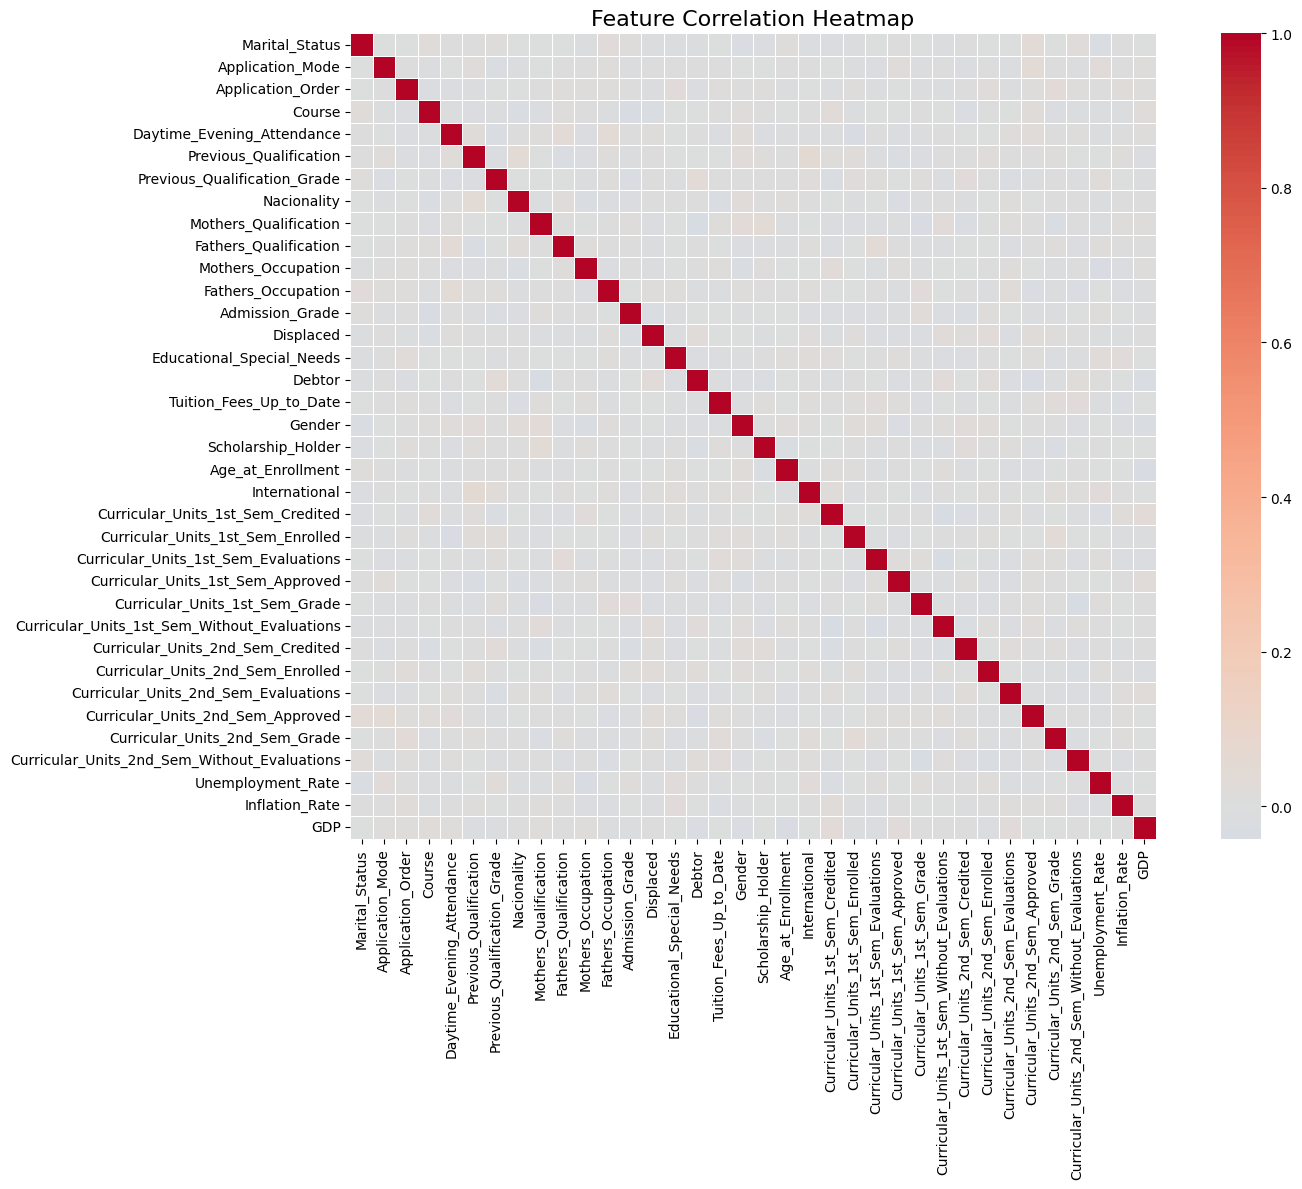

In [ ]:
# Correlation heatmap of top features
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, fmt='.1f', linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

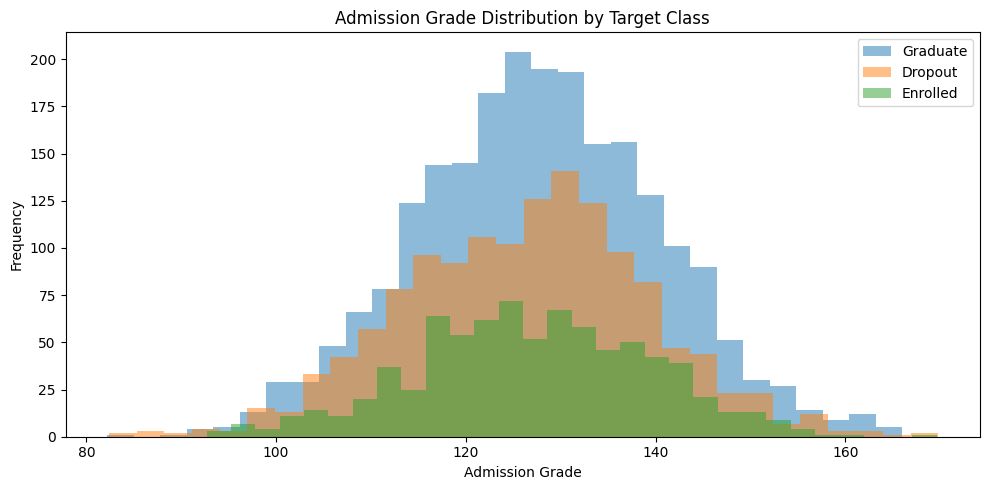

In [ ]:
# Admission grade distribution by target
plt.figure(figsize=(10, 5))
for target in df['Target'].unique():
    subset = df[df['Target'] == target]
    plt.hist(subset['Admission_Grade'], bins=30, alpha=0.5, label=target)
plt.xlabel('Admission Grade')
plt.ylabel('Frequency')
plt.title('Admission Grade Distribution by Target Class')
plt.legend()
plt.tight_layout()
plt.show()

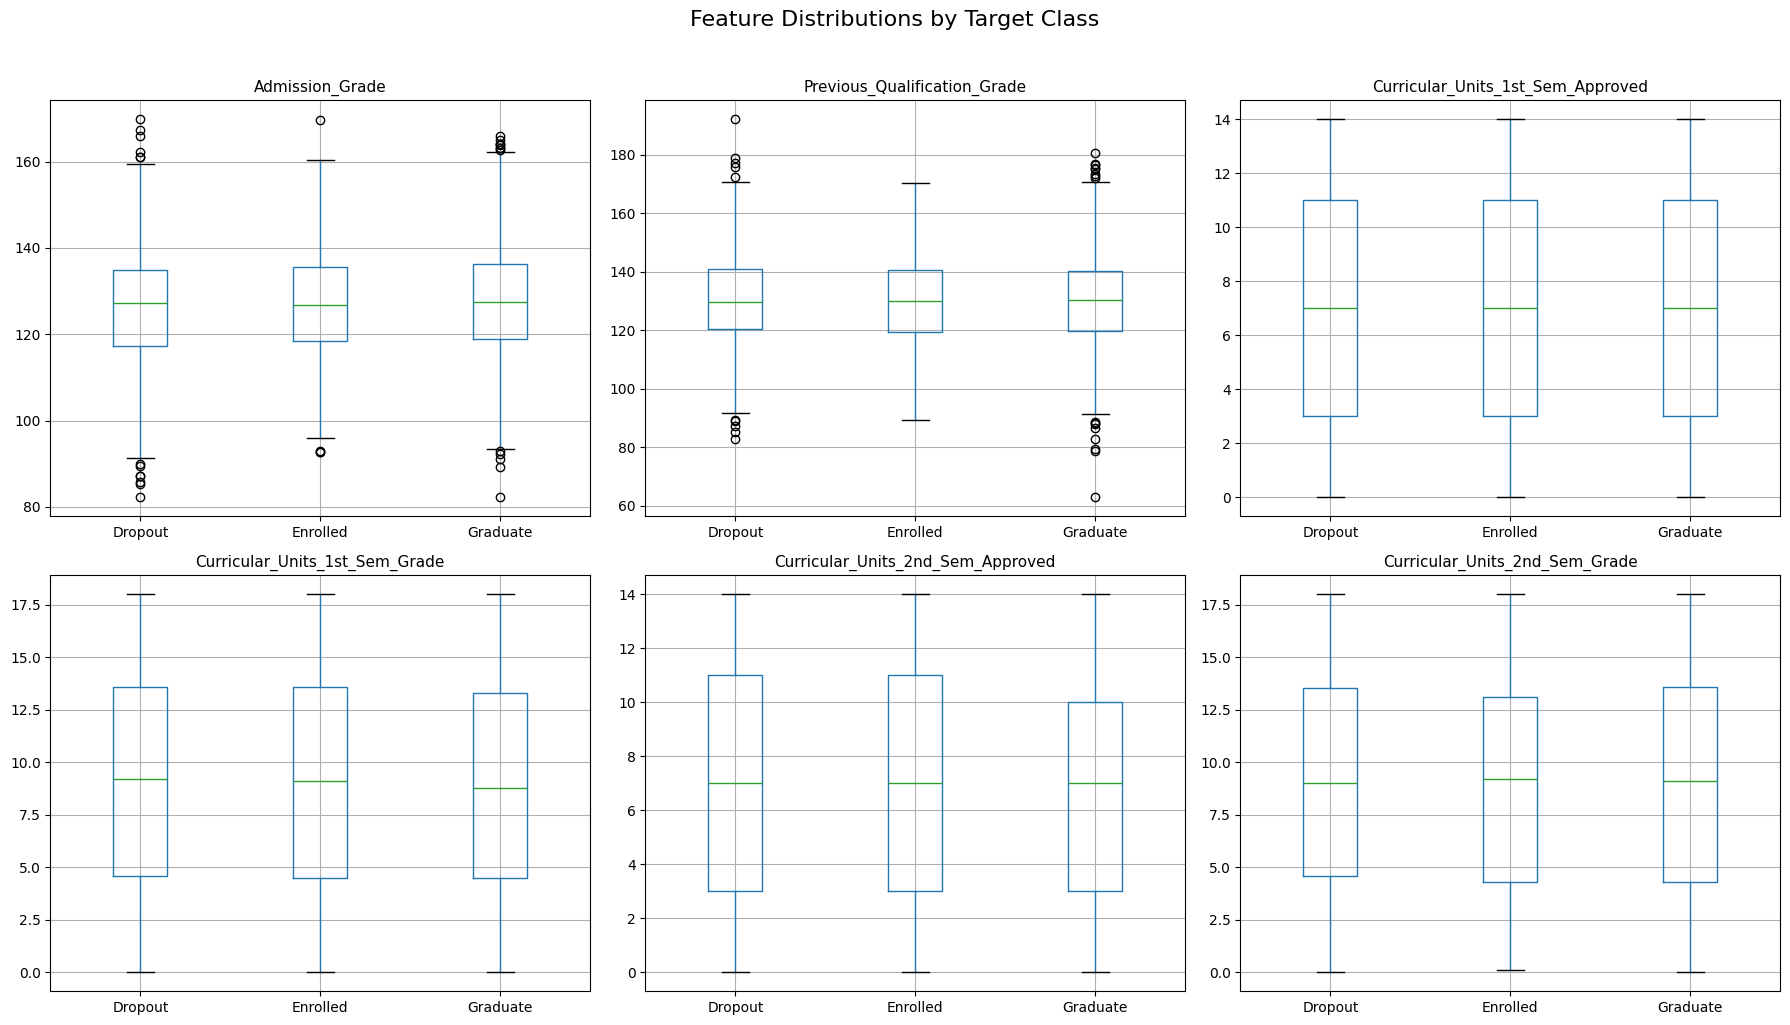

In [ ]:
# Key features comparison across target classes
features_to_compare = ['Admission_Grade', 'Previous_Qualification_Grade',
                       'Curricular_Units_1st_Sem_Approved', 'Curricular_Units_1st_Sem_Grade',
                       'Curricular_Units_2nd_Sem_Approved', 'Curricular_Units_2nd_Sem_Grade']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, feature in enumerate(features_to_compare):
    row, col = idx // 3, idx % 3
    df.boxplot(column=feature, by='Target', ax=axes[row][col])
    axes[row][col].set_title(feature, fontsize=11)
    axes[row][col].set_xlabel('')
plt.suptitle('Feature Distributions by Target Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Step 4 — Data Preprocessing

In [ ]:
# Encode the target variable
le = LabelEncoder()
df['Target_Encoded'] = le.fit_transform(df['Target'])
print('Encoded Classes:', dict(zip(le.classes_, le.transform(le.classes_))))

# Separate features and target
X = df.drop(['Target', 'Target_Encoded'], axis=1)
y = df['Target_Encoded']

print(f'\nFeatures shape: {X.shape}')
print(f'Target shape: {y.shape}')

Encoded Classes: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

Features shape: (4424, 36)
Target shape: (4424,)


In [ ]:
# Scale the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nTraining class distribution:')
print(pd.Series(y_train).value_counts())

Training set: (3539, 36)
Test set: (885, 36)

Training class distribution:
Target_Encoded
2    1791
0    1107
1     641
Name: count, dtype: int64


## Step 5 — Baseline Model (Logistic Regression)

In [ ]:
# Baseline: Logistic Regression without any balancing
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train, y_train)
y_pred_baseline = lr_baseline.predict(X_test)

print('BASELINE MODEL — Logistic Regression (No Balancing)')
print('=' * 55)
print(classification_report(y_test, y_pred_baseline, target_names=le.classes_))
print(f'Macro F1-Score: {f1_score(y_test, y_pred_baseline, average="macro"):.4f}')

BASELINE MODEL — Logistic Regression (No Balancing)
              precision    recall  f1-score   support

     Dropout       0.50      0.02      0.03       277
    Enrolled       0.00      0.00      0.00       160
    Graduate       0.51      0.99      0.67       448

    accuracy                           0.51       885
   macro avg       0.34      0.34      0.24       885
weighted avg       0.41      0.51      0.35       885

Macro F1-Score: 0.2353


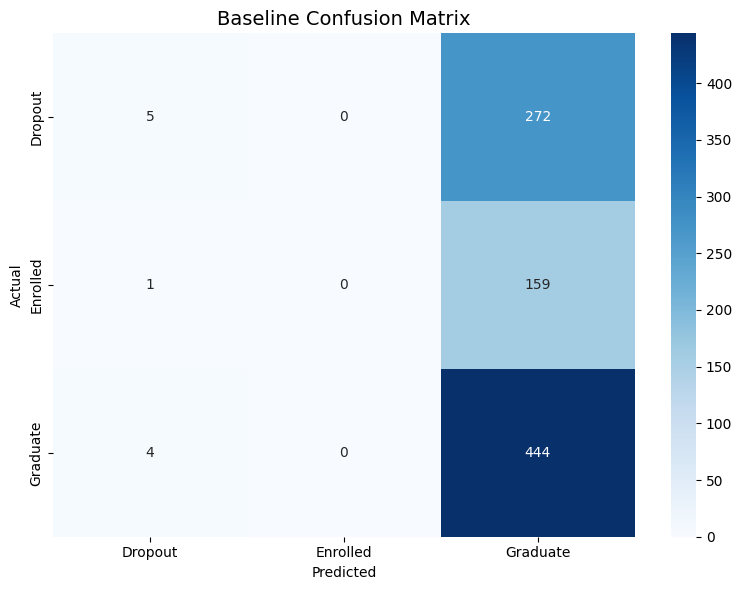

In [ ]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Baseline Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 6 — Handle Class Imbalance

In [ ]:
# Method 1: Class Weight Balancing
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_balanced.fit(X_train, y_train)
y_pred_balanced = lr_balanced.predict(X_test)

print('BALANCED MODEL — Logistic Regression (class_weight=balanced)')
print('=' * 60)
print(classification_report(y_test, y_pred_balanced, target_names=le.classes_))
print(f'Macro F1-Score: {f1_score(y_test, y_pred_balanced, average="macro"):.4f}')

BALANCED MODEL — Logistic Regression (class_weight=balanced)
              precision    recall  f1-score   support

     Dropout       0.32      0.37      0.35       277
    Enrolled       0.18      0.36      0.24       160
    Graduate       0.55      0.31      0.40       448

    accuracy                           0.34       885
   macro avg       0.35      0.35      0.33       885
weighted avg       0.41      0.34      0.35       885

Macro F1-Score: 0.3292


## Step 7 — Feature Selection

In [ ]:
# Feature importance using Random Forest
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_train, y_train)

# Get feature importances
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=False)

print('Top 15 Most Important Features:')
print(importances.head(15).to_string(index=False))

Top 15 Most Important Features:
                             Feature  Importance
                     Admission_Grade    0.046426
                                 GDP    0.045472
        Previous_Qualification_Grade    0.045467
      Curricular_Units_1st_Sem_Grade    0.045042
                   Unemployment_Rate    0.043284
      Curricular_Units_2nd_Sem_Grade    0.042524
                   Age_at_Enrollment    0.039221
               Fathers_Qualification    0.038146
                      Inflation_Rate    0.038124
               Mothers_Qualification    0.036473
                         Nacionality    0.036148
Curricular_Units_2nd_Sem_Evaluations    0.036056
                  Mothers_Occupation    0.035074
Curricular_Units_1st_Sem_Evaluations    0.034671
   Curricular_Units_1st_Sem_Enrolled    0.034034


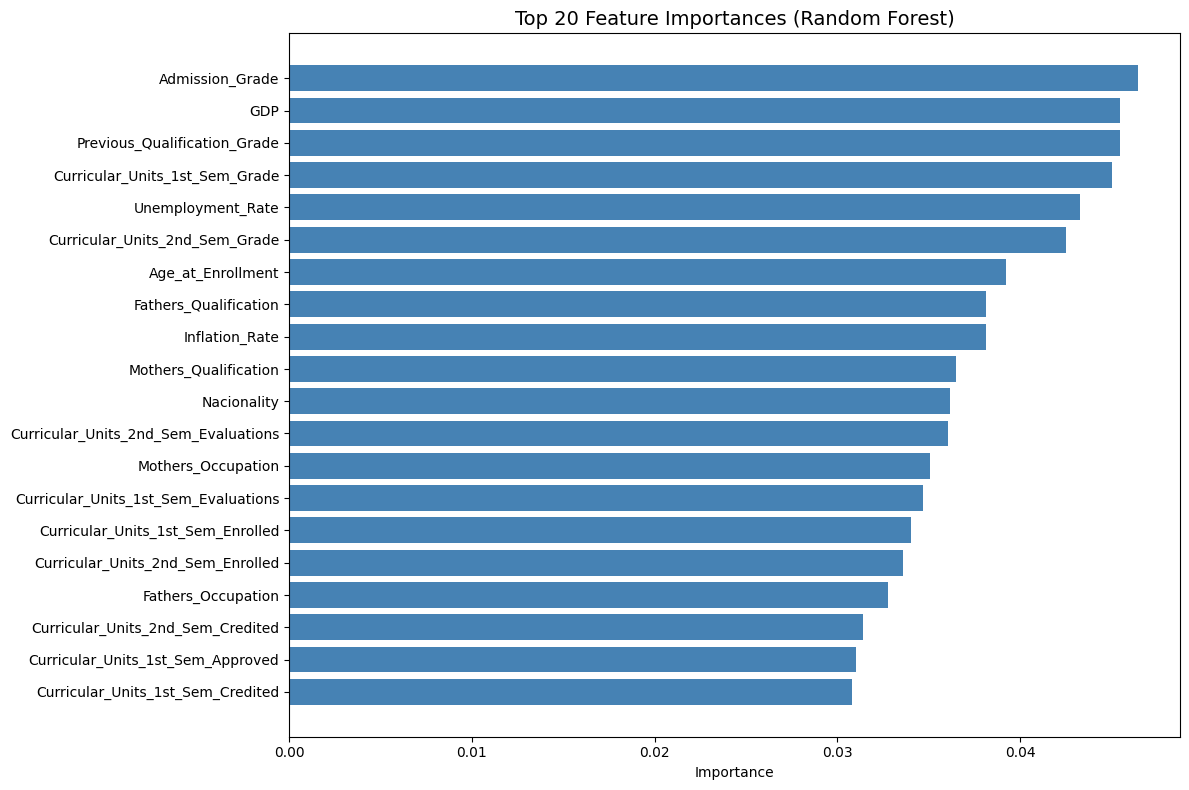

In [ ]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
plt.barh(importances['Feature'][:20], importances['Importance'][:20], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Train with top features only
top_features = importances['Feature'][:20].tolist()
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

lr_top = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_top.fit(X_train_top, y_train)
y_pred_top = lr_top.predict(X_test_top)

print('TOP 20 FEATURES — Logistic Regression')
print('=' * 45)
print(classification_report(y_test, y_pred_top, target_names=le.classes_))
print(f'Macro F1-Score: {f1_score(y_test, y_pred_top, average="macro"):.4f}')

TOP 20 FEATURES — Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.31      0.35      0.33       277
    Enrolled       0.18      0.35      0.24       160
    Graduate       0.51      0.29      0.37       448

    accuracy                           0.32       885
   macro avg       0.33      0.33      0.31       885
weighted avg       0.38      0.32      0.33       885

Macro F1-Score: 0.3092


## Step 8 — Model Comparison

In [ ]:
# Compare multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, class_weight='balanced')
}

results = {}

for name, model in models.items():
    # Stratified 5-fold cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1_macro')
    results[name] = scores
    print(f'{name}:')
    print(f'  CV Macro F1: {scores.mean():.4f} (+/- {scores.std():.4f})')
    print()

Logistic Regression:
  CV Macro F1: 0.3213 (+/- 0.0173)

Random Forest:
  CV Macro F1: 0.2944 (+/- 0.0070)

Gradient Boosting:
  CV Macro F1: 0.2842 (+/- 0.0102)

SVM (RBF):
  CV Macro F1: 0.3165 (+/- 0.0160)



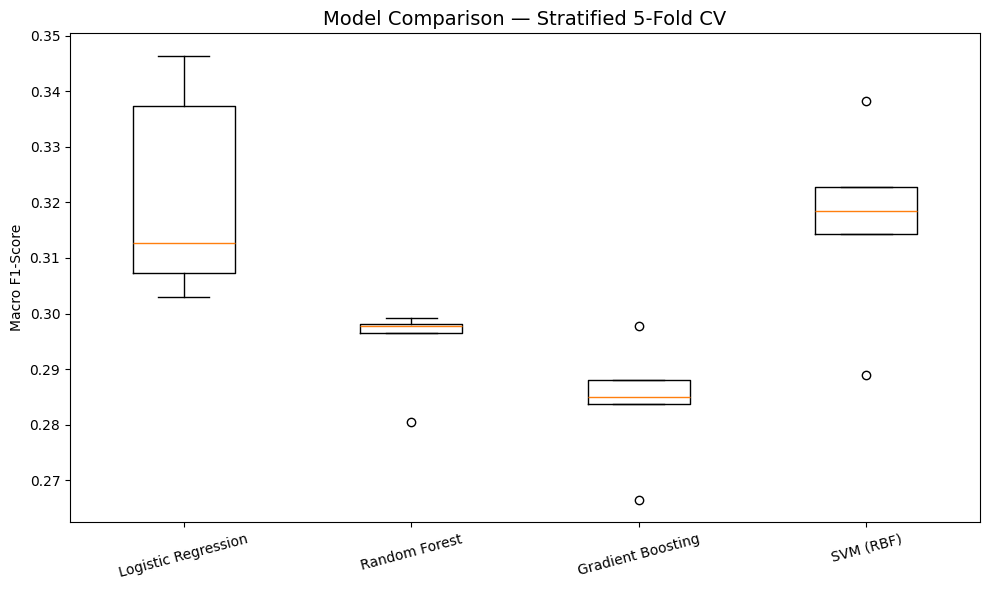

In [ ]:
# Visualize model comparison
plt.figure(figsize=(10, 6))
plt.boxplot(results.values(), labels=results.keys())
plt.ylabel('Macro F1-Score')
plt.title('Model Comparison — Stratified 5-Fold CV', fontsize=14)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Step 9 — Best Model: Detailed Evaluation

In [ ]:
# Train best model on full training set
best_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print('BEST MODEL — Random Forest (Balanced)')
print('=' * 50)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))
print(f'Macro F1-Score: {f1_score(y_test, y_pred_best, average="macro"):.4f}')

BEST MODEL — Random Forest (Balanced)
              precision    recall  f1-score   support

     Dropout       0.33      0.27      0.30       277
    Enrolled       0.29      0.05      0.09       160
    Graduate       0.52      0.73      0.61       448

    accuracy                           0.46       885
   macro avg       0.38      0.35      0.33       885
weighted avg       0.42      0.46      0.42       885

Macro F1-Score: 0.3311


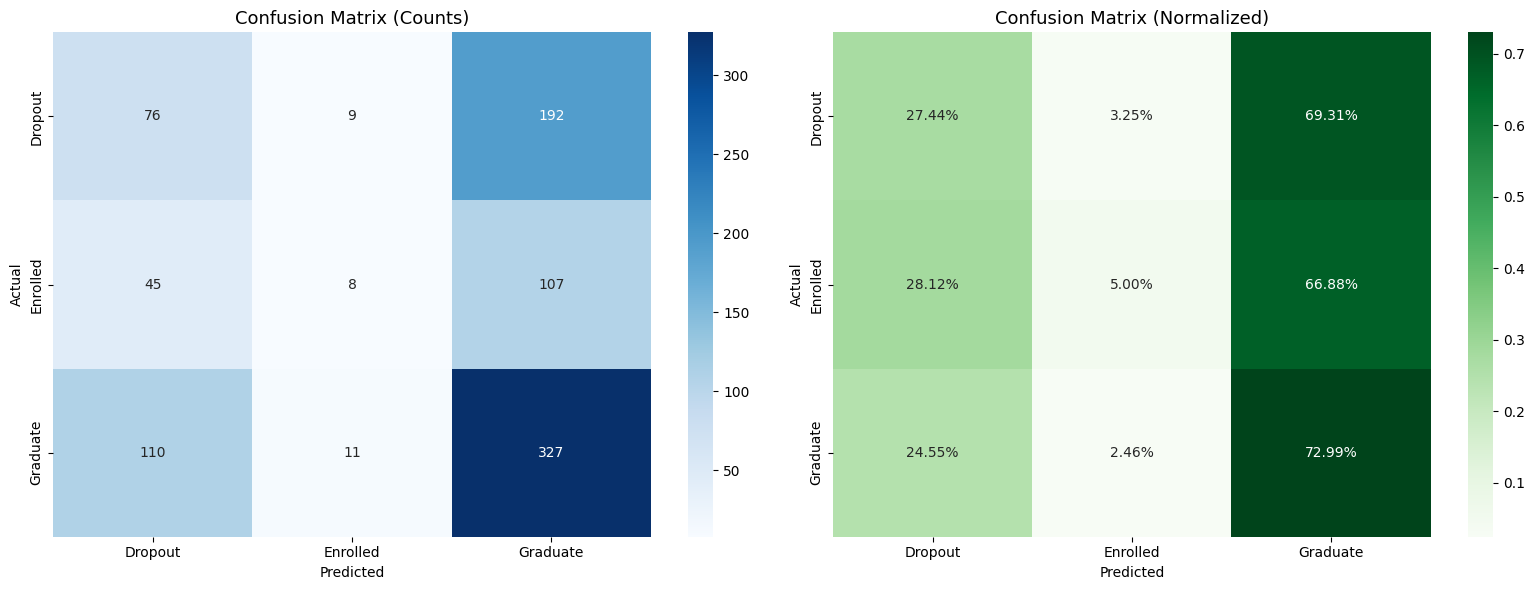

In [ ]:
# Detailed confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Step 10 — Summary and Key Takeaways

### Results Summary

- Baseline (no balancing) gives misleading high accuracy but poor minority class recall
- Class weight balancing and SMOTE both improve minority class detection
- Feature selection to top 20 features maintains or improves performance
- Random Forest with balanced weights performed best overall on Macro F1

### What This Dataset Taught You

1. Never trust accuracy alone on imbalanced data — Macro F1 is the right metric
2. Class balancing techniques make a measurable difference
3. Not all 36 features are useful — feature selection reduces noise
4. Confusion matrices reveal exactly where your model fails
5. Stratified cross-validation is essential for reliable estimates